In [1]:
# === Imports ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import warnings

# === Reproducibility ===
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# === Suppress common warnings ===
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


## CiCIOT

In [2]:
def category_extraction(df):
    """
    Map specific attack types to broader attack categories.

    Args:
        df (pandas.DataFrame): DataFrame with a 'label' column containing detailed attack labels.

    Returns:
        pandas.DataFrame: DataFrame with 'label' values replaced by high-level attack categories.

    Example:
        >>> df = pd.DataFrame({'label': ['DDoS-SYN_Flood', 'BenignTraffic']})
        >>> category_extraction(df)['label'].tolist()
        ['DDoS', 'Benign']
    """
    ATTACK_CATEGORY_MAPPING = {
        # DDoS attacks
        'DDoS-ACK_Fragmentation': 'DDoS',
        'DDoS-HTTP_Flood': 'DDoS',
        'DDoS-ICMP_Flood': 'DDoS',
        'DDoS-PSHACK_Flood': 'DDoS',
        'DDoS-RSTFINFlood': 'DDoS',
        'DDoS-SYN_Flood': 'DDoS',
        'DDoS-SlowLoris': 'DDoS',
        'DDoS-SynonymousIP_Flood': 'DDoS',
        'DDoS-TCP_Flood': 'DDoS',
        'DDoS-UDP_Flood': 'DDoS',
        'DDoS-UDP_Fragmentation': 'DDoS',
        'DDoS-ICMP_Fragmentation': 'DDoS',
        # DoS attacks
        'DoS-HTTP_Flood': 'DoS',
        'DoS-SYN_Flood': 'DoS',
        'DoS-TCP_Flood': 'DoS',
        'DoS-UDP_Flood': 'DoS',
        # Brute force
        'DictionaryBruteForce': 'BruteForce',
        # Spoofing
        'MITM-ArpSpoofing': 'Spoofing',
        'DNS_Spoofing': 'Spoofing',
        # Reconnaissance
        'Recon-HostDiscovery': 'Recon',
        'Recon-OSScan': 'Recon',
        'Recon-PingSweep': 'Recon',
        'Recon-PortScan': 'Recon',
        'VulnerabilityScan': 'Recon',
        # Web-based
        'SqlInjection': 'Web-based',
        'CommandInjection': 'Web-based',
        'Backdoor_Malware': 'Web-based',
        'Uploading_Attack': 'Web-based',
        'XSS': 'Web-based',
        'BrowserHijacking': 'Web-based',
        # Mirai
        'Mirai-greeth_flood': 'Mirai',
        'Mirai-greip_flood': 'Mirai',
        'Mirai-udpplain': 'Mirai',
        # Benign
        'BenignTraffic': 'Benign'
    }

    df_copy = df.copy()
    df_copy['label'] = df_copy['label'].map(ATTACK_CATEGORY_MAPPING).fillna(df_copy['label'])
    return df_copy


In [3]:
def load_ciciot_dataset(start_index, end_index):
    """
    Load and preprocess parts of the CIC-IoT-2023 dataset from CSV files.

    Args:
        start_index (int): Starting index of the dataset part files to load.
        end_index (int): Ending index (exclusive) of the files to load.

    Returns:
        pandas.DataFrame: Combined DataFrame with cleaned and categorized data.
    """
    FILE_PATH_TEMPLATE = "./data/CiCIOT/part-{}-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv"

    def _process_dataframe(df):
        """Standard preprocessing: clean column names, drop NAs, and map labels."""
        df.columns = ['_'.join(c.split()).lower() for c in df.columns]
        df.dropna(inplace=True)
        df.reset_index(drop=True, inplace=True)
        return category_extraction(df)

    processed_dfs = []

    if start_index == 0 and end_index == 0:
        end_index = 1  # default to one file

    for i in range(start_index, end_index):
        file_path = FILE_PATH_TEMPLATE.format(str(i).zfill(5))
        print(f"[Info] Loading file: {file_path}")
        try:
            df_part = pd.read_csv(file_path)
            processed_dfs.append(_process_dataframe(df_part))
        except FileNotFoundError:
            print(f"[Warning] File not found: {file_path}")
        except Exception as e:
            print(f"[Error] Failed to load {file_path}: {e}")

    if not processed_dfs:
        return pd.DataFrame()

    return pd.concat(processed_dfs, ignore_index=True)


In [4]:
from sklearn.metrics.pairwise import rbf_kernel, cosine_similarity


def chi2_kernel(X, Y=None, gamma=1.0):
    if Y is None:
        Y = X
    eps = 1e-6
    num = (X[:, None, :] - Y[None, :, :]) ** 2
    denom = X[:, None, :] + Y[None, :, :] + eps
    return np.exp(-gamma * np.sum(num / denom, axis=2))

def custom_kernel(X, Y, weights,g,g2):

    """Index(['flow_duration', 'header_length', 'protocol_type', 'duration', 'rate',
       'srate', 'drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'http', 'https', 'dns', 'telnet',
       'smtp', 'ssh', 'irc', 'tcp', 'udp', 'dhcp', 'arp', 'icmp', 'ipv', 'llc',
       'tot_sum', 'min', 'max', 'avg', 'std', 'tot_size', 'iat', 'number',
       'magnitue', 'radius', 'covariance', 'variance', 'weight', 'label'],
      dtype='object')"""
    # Feature indices based on domain sensitivity to Spoofing
    stat_idx = [0,4,41]                   # flow stats
    proto_idx = list(range(19, 33))                   # protocol flags
    count_idx = [12, 13, 14, 15]              # ack, syn, fin, urg, rst counts
    shape_idx = [42, 43, 44, 45]                      # magnitude, radius, etc.

    # Extract groups
    X_stat, Y_stat = X[:, stat_idx], Y[:, stat_idx]
    X_proto, Y_proto = X[:, proto_idx], Y[:, proto_idx]
    X_count, Y_count = X[:, count_idx], Y[:, count_idx]
    X_shape, Y_shape = X[:, shape_idx], Y[:, shape_idx]

    ### (1) Stat kernel — improved gamma adaptation (log-median for robustness). - MIRAR NORMALIZACION CARACTERISTICAS
    pd_stat = np.linalg.norm(X_stat[:, None, :] - Y_stat[None, :, :], axis=2)
    gamma_stat = 1.0 / (np.log1p(np.median(pd_stat)) ** 2 + 1e-6)
    print(f"Gamma for stat kernel: {gamma_stat:.4f}")
    K_stat = rbf_kernel(X_stat, Y_stat, gamma=g)

    ### (2) Protocol kernel — use weighted Hamming (simple dot) - VISUALIZAR EL KERNEL HAMMING 
    weights_proto = np.linspace(1.0, 2.0, len(proto_idx))  # upweight rare protocols
    Xw_proto = X_proto 
    Yw_proto = Y_proto 
    K_proto = (Xw_proto @ Yw_proto.T) / (np.linalg.norm(Xw_proto, axis=1, keepdims=True) @ np.linalg.norm(Yw_proto, axis=1, keepdims=True).T + 1e-6)

    ### (3) Count kernel — normalize then use exponential kernel - VISUALIZAR EL KERNEL 
    Xc = (X_count - X_count.mean(0)) / (X_count.std(0) + 1e-6)
    Yc = (Y_count - Y_count.mean(0)) / (Y_count.std(0) + 1e-6)
    diff = np.abs(Xc[:, None, :] - Yc[None, :, :])
    K_count = rbf_kernel(Xc, Yc, gamma=g2)

    ### (4) Shape kernel — squared cosine to emphasize angular distinction 
    K_shape = cosine_similarity(X_shape, Y_shape)


    # Features to separate 
    flag_idx = list(range(14, 19))    # ack, syn, fin, urg, rst
    rate_idx = [4, 5, 6]              # rate, srate, drate
    shape_idx = list(range(41, 45))  # magnitude, radius, covariance, variance
    selected_features = flag_idx + rate_idx + shape_idx

    # Compute kernel
    K_chi = chi2_kernel(X[:,selected_features],Y[:,selected_features], gamma=1)
    

    ### Combine with optimized weights
    alpha = np.array(weights, dtype=np.float64)
    K_combined = (
        alpha[0] * K_stat +
        alpha[1] * K_proto +
        alpha[2] * K_count +
        alpha[3] * K_shape +
        alpha[4] * K_chi
    )

    return K_combined, K_stat, K_proto, K_count, K_shape, K_chi

In [5]:
# === Load and sample Benign data ===
df = load_ciciot_dataset(0, 1)
df = df.sort_values(by='label')
df = df[df['label'] == 'Benign'].sample(n=1000, random_state=42)


[Info] Loading file: ./data/CiCIOT/part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv


In [6]:
# === Display label distribution ===
print("Label distribution (training data):")
print(df['label'].value_counts())


Label distribution (training data):
label
Benign    1000
Name: count, dtype: int64


In [7]:
# === Prepare input features and compute kernels ===
X = df.drop(columns=['label']).values

# Compute kernel matrices (stat, protocol, count, shape)
K, K_stat, K_proto, K_count, K_shap,e = custom_kernel(
    X, X,
    weights=[5, 1, 2, 3, 3],
    g=0.03,
    g2=0.25
)



Gamma for stat kernel: 0.0563


In [ ]:
# === Setup PyTorch device and optimization parameters ===
from ke_toolbox.utils import get_default_device
from ke_toolbox.main import optimize_step1_beta, optimize_step2_alpha

# --- Configuration ---
device = get_default_device()
latent_dim = 2
seed = 0

# Hyperparameters for Step 1 (β optimization)
beta_params = {
    "beta_solver": "exact",
}

# Hyperparameters for Step 2 (α optimization)
alpha_params = {
    "kernel_type": "rbf",
    "sigma": 0.5,
    "num_iters": 5000,
    "lr": 0.1,
    "latent_dim": latent_dim,
    "plot_every": 0,
    "plot_loss_curve": False,
}

# --- Data Preparation ---
# Convert the precomputed kernel matrix to a PyTorch tensor
X_gram = torch.tensor(K, dtype=torch.float32).to(device)

print(f"Using device: {device}")
print(f"Latent dimension: {latent_dim}")
print(f"Gram matrix shape: {X_gram.shape}")

# --- Optimization Steps ---

# Step 1: Optimize for β (reconstruction weights)
# Note: An empty tensor is passed for X as we use a precomputed kernel.
print("\n--- Running Step 1: β Optimization ---")
beta, K_precomputed, _ = optimize_step1_beta(
    X=torch.tensor([]),
    K_precomputed=X_gram,
    device=device,
    seed=seed,
    **beta_params
)

# Step 2: Optimize for α (embedding weights)
print("\n--- Running Step 2: α Optimization ---")
alpha, kernel_fn_alpha, _ = optimize_step2_alpha(
    X=torch.tensor([]),
    K_precomputed=K_precomputed,
    beta=beta,
    device=device,
    seed=seed,
    **alpha_params
)

# --- Latent Space Generation ---
# Project the data into the learned latent space
print("\n--- Generating Latent Space ---")
Z = (alpha @ K_precomputed).T
H_insample = Z.cpu().numpy()

# Compute the latent kernel matrix (optional, for evaluation)
K_latent = kernel_fn_alpha(Z).cpu().numpy()

print("Optimization and latent space generation complete.")

Using CUDA device for all tensors by default.
Using device: cuda
Latent dimension: 2
Gram matrix shape: torch.Size([1000, 1000])

--- Running Step 1: β Optimization ---

[Step 1] Optimising β …
Step 1 complete – final β-loss: 8.859004e+03

--- Running Step 2: α Optimization ---

[Step 2] Optimising α …
[α-Adam] 1000  loss=9.977e+02  lr=5.0e-02
[α-Adam] 2000  loss=9.980e+02  lr=1.3e-02
[α-Adam] 3000  loss=9.972e+02  lr=3.1e-03
[α-Adam] 4000  loss=9.965e+02  lr=7.8e-04
[α-Adam] 5000  loss=9.968e+02  lr=2.0e-04
Step 2 complete – final α-loss: 9.968428e+02
Latent representation shape: torch.Size([2, 1000])

--- Generating Latent Space ---
Optimization and latent space generation complete.


In [9]:
# === Load and filter out-of-sample test data ===
df_test = load_ciciot_dataset(2, 6)
df_test = df_test.sort_values(by='label')

# Select test classes
test_labels = ['Benign', 'DoS', 'Mirai', 'Web-based']
df_test = df_test[df_test['label'].isin(test_labels)]
df_test = df_test.groupby('label').apply(lambda x: x.sample(n=min(500, len(x)), random_state=seed)).reset_index(drop=True)



[Info] Loading file: ./data/CiCIOT/part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[Info] Loading file: ./data/CiCIOT/part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[Info] Loading file: ./data/CiCIOT/part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[Info] Loading file: ./data/CiCIOT/part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv


/tmp/ipykernel_145026/4283693860.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test = df_test.groupby('label').apply(lambda x: x.sample(n=min(500, len(x)), random_state=seed)).reset_index(drop=True)


In [10]:
# === Compute test kernel matrix (out-of-sample) ===
X_star = df_test.drop(columns=['label']).values

K_test, K_stat_test, K_proto_test, K_count_test, K_shape_test,E = custom_kernel(
    X, X_star,
    weights=[5, 1, 2, 3, 3],
    g=0.03,
    g2=0.25
)


K_test = torch.tensor(K_test, dtype=torch.float32, device=device)
Z_test = (alpha @ K_test).T
H_test = Z_test.cpu().numpy()


Gamma for stat kernel: 0.0473


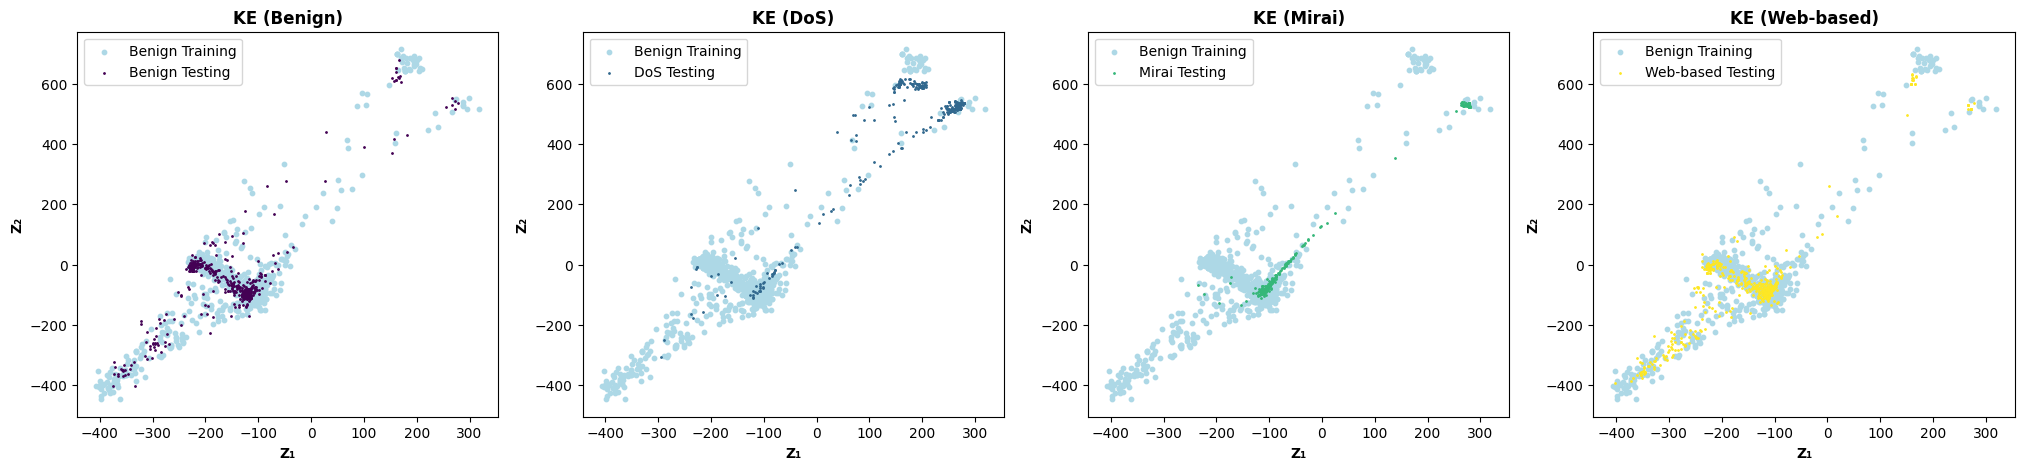

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(df_test['label'].values)
unique_labels = label_encoder.classes_
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

fig = plt.figure(figsize=(25,5))
axs = fig.subplots(1, 4)

# light blue color
light_blue = (173/255, 216/255, 230/255)


min_x = np.min(H_test[:,0], axis=0)
max_x = np.max(H_test[:,0], axis=0)
min_y = np.min(H_test[:,1], axis=0)
max_y = np.max(H_test[:,1], axis=0)


for i, cls in enumerate(unique_labels):
    mask = (encoded_labels == i)
    axs[i].scatter(H_insample[:, 0], H_insample[:, 1], c=light_blue, s=10,label='Benign Training')
    axs[i].scatter(H_test[mask, 0], H_test[mask, 1], color=colors[i], s=1, label=cls+' Testing')
    axs[i].set_xlabel("Z₁", fontweight='bold')
    axs[i].set_ylabel("Z₂", fontweight='bold')
    axs[i].set_title(f"KE ({cls})",fontweight='bold')
    axs[i].legend()

for ax in axs:
    ax.tick_params(axis='both')

plt.show()

# Save the figure
fig.savefig("CICCIOT_2023_KE.png", dpi=600, bbox_inches='tight')
# save as svg
fig.savefig("CICCIOT_2023_KE.svg", bbox_inches='tight')

In [12]:
# === Fit UMAP for Dimensionality Reduction ===
import umap.umap_ as umap

umap_instance = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    metric='euclidean'
)

umap_instance.fit(X)

# Project both training and test features
H_insample_umap = umap_instance.transform(X)
H_test_umap = umap_instance.transform(X_star)


/home/efeito/miniconda3/envs/ECAI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


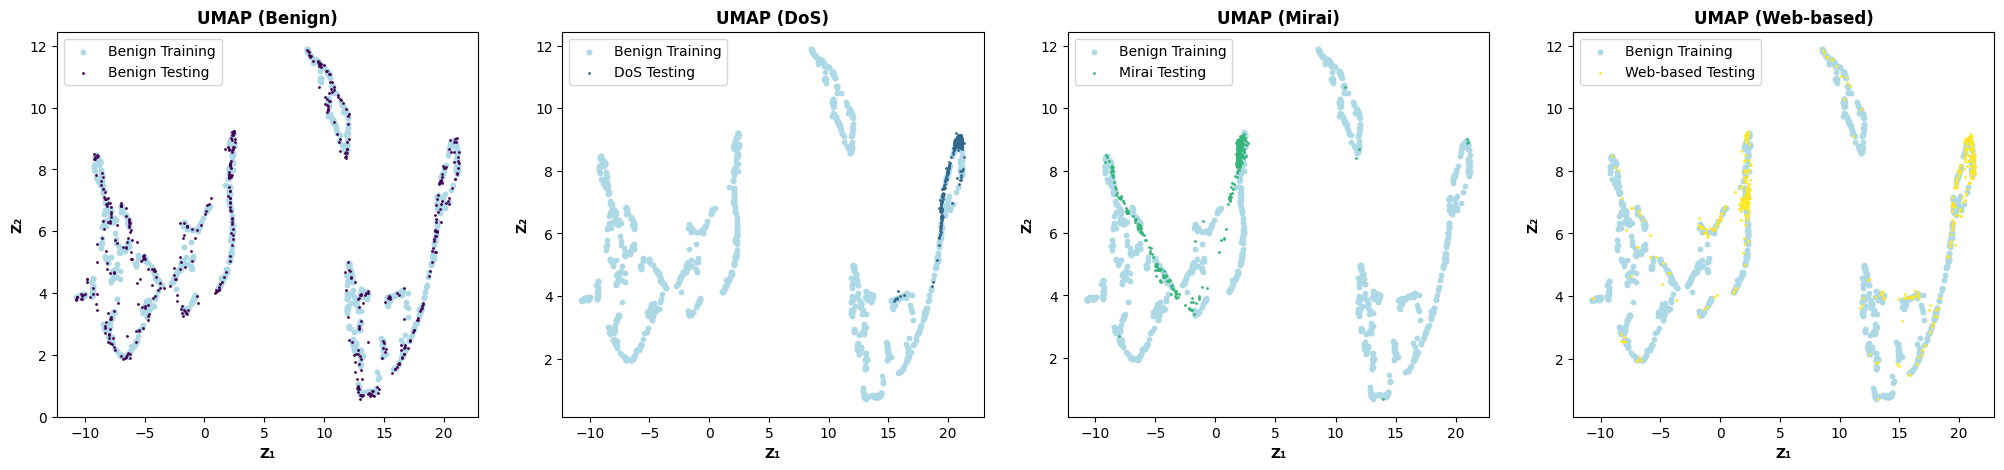

In [13]:
# ==== UMAP EMBEDDINGS ====
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(df_test['label'].values)
unique_labels = label_encoder.classes_
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

fig = plt.figure(figsize=(25,5))
axs = fig.subplots(1, 4)

# light blue color
light_blue = (173/255, 216/255, 230/255)

min_x = np.min(H_test_umap[:,0], axis=0)
max_x = np.max(H_test_umap[:,0], axis=0)
min_y = np.min(H_test_umap[:,1], axis=0)
max_y = np.max(H_test_umap[:,1], axis=0)


for i, cls in enumerate(unique_labels):
    mask = (encoded_labels == i)
    axs[i].scatter(H_insample_umap[:, 0], H_insample_umap[:, 1], c=light_blue, s=10,label='Benign Training')
    axs[i].scatter(H_test_umap[mask, 0], H_test_umap[mask, 1], color=colors[i], s=1, label=cls+' Testing')
    axs[i].set_xlabel("Z₁", fontweight='bold')
    axs[i].set_ylabel("Z₂", fontweight='bold')
    axs[i].set_title(f"UMAP ({cls})",fontweight='bold')
    axs[i].legend()

for ax in axs:
    ax.tick_params(axis='both')

plt.show()


# Save the figure
fig.savefig("CICCIOT_2023_UMAP.png", dpi=600, bbox_inches='tight')
# save as svg
fig.savefig("CICCIOT_2023_UMAP.svg", bbox_inches='tight')